# Modeling: Klasifikasi Berita dengan Naive Bayes

Tahap ini melatih model klasifikasi **Naive Bayes** untuk membedakan artikel `sport` dan `finance`, menggunakan tiga representasi data yang telah disiapkan pada tahap Vectorization: **TF-IDF**, **PCA**, dan **Truncated SVD**. Performa ketiganya dibandingkan untuk melihat representasi mana yang memberikan hasil terbaik pada dataset ini.

```{admonition} Kenapa Naive Bayes?
:class: note

Naive Bayes adalah salah satu algoritma klasifikasi paling umum untuk data teks karena sederhana, cepat dilatih, dan bekerja cukup baik meskipun asumsinya (fitur saling independen) jarang benar-benar terpenuhi di dunia nyata. Variannya dipilih sesuai jenis data:
- **MultinomialNB**: cocok untuk data non-negatif seperti TF-IDF (mewakili frekuensi/bobot kata).
- **GaussianNB**: cocok untuk data kontinu yang bisa bernilai negatif, seperti hasil PCA/SVD.
```

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_tfidf = pd.read_excel("../data/dataset_tfidf.xlsx")
df_pca = pd.read_excel("../data/dataset_pca.xlsx")
df_svd = pd.read_excel("../data/dataset_svd.xlsx")

print("TF-IDF:", df_tfidf.shape)
print("PCA   :", df_pca.shape)
print("SVD   :", df_svd.shape)

TF-IDF: (200, 2560)
PCA   : (200, 108)
SVD   : (200, 109)


## 1. Siapkan Data Latih & Data Uji

Pembagian data latih/uji dibuat **identik** untuk ketiga representasi (berdasarkan `doc_id` yang sama), agar perbandingan performa antar representasi adil - bukan disebabkan oleh perbedaan pembagian data.

In [11]:
doc_id_latih, doc_id_uji = train_test_split(
    df_tfidf["doc_id"], test_size=0.2, stratify=df_tfidf["label_asli"], random_state=42
)

print(f"Jumlah data latih: {len(doc_id_latih)}")
print(f"Jumlah data uji  : {len(doc_id_uji)}")

Jumlah data latih: 160
Jumlah data uji  : 40


In [12]:
def siapkan_fitur_label(df, kolom_buang):
    fitur = df.drop(columns=kolom_buang)
    label = df["label_asli"]
    return fitur, label

kolom_bukan_fitur = ["doc_id", "label_asli"] + [c for c in df_tfidf.columns if c.startswith("label_")]

X_tfidf, y_tfidf = siapkan_fitur_label(df_tfidf, kolom_bukan_fitur)
X_pca, y_pca = siapkan_fitur_label(df_pca, [c for c in df_pca.columns if c in kolom_bukan_fitur])
X_svd, y_svd = siapkan_fitur_label(df_svd, [c for c in df_svd.columns if c in kolom_bukan_fitur])

print("Jumlah fitur TF-IDF:", X_tfidf.shape[1])
print("Jumlah fitur PCA   :", X_pca.shape[1])
print("Jumlah fitur SVD   :", X_svd.shape[1])

Jumlah fitur TF-IDF: 2556
Jumlah fitur PCA   : 104
Jumlah fitur SVD   : 105


## 2. Latih & Evaluasi Naive Bayes untuk Tiap Representasi

In [13]:
def latih_dan_evaluasi(X, y, doc_id_kolom, model_class, nama):
    mask_latih = doc_id_kolom.isin(doc_id_latih)
    mask_uji = doc_id_kolom.isin(doc_id_uji)

    X_latih, X_uji = X[mask_latih], X[mask_uji]
    y_latih, y_uji = y[mask_latih], y[mask_uji]

    model = model_class()
    model.fit(X_latih, y_latih)
    prediksi = model.predict(X_uji)

    akurasi = accuracy_score(y_uji, prediksi)
    print(f"=== {nama} ===")
    print(f"Akurasi: {akurasi:.4f}\n")
    print(classification_report(y_uji, prediksi))

    return {"nama": nama, "akurasi": akurasi, "y_uji": y_uji, "prediksi": prediksi}

hasil_tfidf = latih_dan_evaluasi(X_tfidf, y_tfidf, df_tfidf["doc_id"], MultinomialNB, "TF-IDF (MultinomialNB)")

=== TF-IDF (MultinomialNB) ===
Akurasi: 0.9750

              precision    recall  f1-score   support

     finance       0.95      1.00      0.98        20
       sport       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



In [14]:
hasil_pca = latih_dan_evaluasi(X_pca, y_pca, df_pca["doc_id"], GaussianNB, "PCA (GaussianNB)")

=== PCA (GaussianNB) ===
Akurasi: 0.9250

              precision    recall  f1-score   support

     finance       0.95      0.90      0.92        20
       sport       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



In [15]:
hasil_svd = latih_dan_evaluasi(X_svd, y_svd, df_svd["doc_id"], GaussianNB, "Truncated SVD (GaussianNB)")

=== Truncated SVD (GaussianNB) ===
Akurasi: 0.9250

              precision    recall  f1-score   support

     finance       0.95      0.90      0.92        20
       sport       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



## 3. Bandingkan Ketiga Representasi

In [16]:
semua_hasil = [hasil_tfidf, hasil_pca, hasil_svd]

ringkasan = pd.DataFrame({
    "Representasi": [h["nama"] for h in semua_hasil],
    "Akurasi": [h["akurasi"] for h in semua_hasil],
    "Jumlah Fitur": [X_tfidf.shape[1], X_pca.shape[1], X_svd.shape[1]],
})
ringkasan

,Representasi,Akurasi,Jumlah Fitur
0,TF-IDF (MultinomialNB),0.975,2556
1,PCA (GaussianNB),0.925,104
2,Truncated SVD (GaussianNB),0.925,105


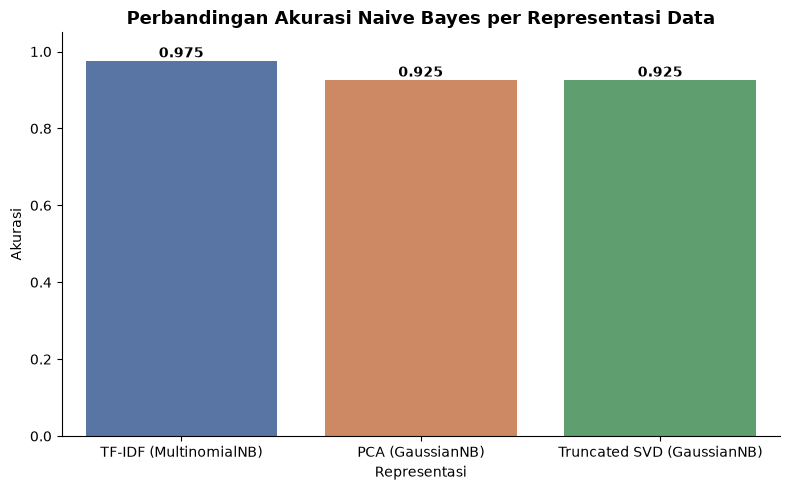

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ringkasan, x="Representasi", y="Akurasi", hue="Representasi",
            palette=["#4C72B0", "#DD8452", "#55A868"], legend=False, ax=ax)
for i, v in enumerate(ringkasan["Akurasi"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_title("Perbandingan Akurasi Naive Bayes per Representasi Data", fontsize=13, fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Confusion Matrix Tiap Representasi

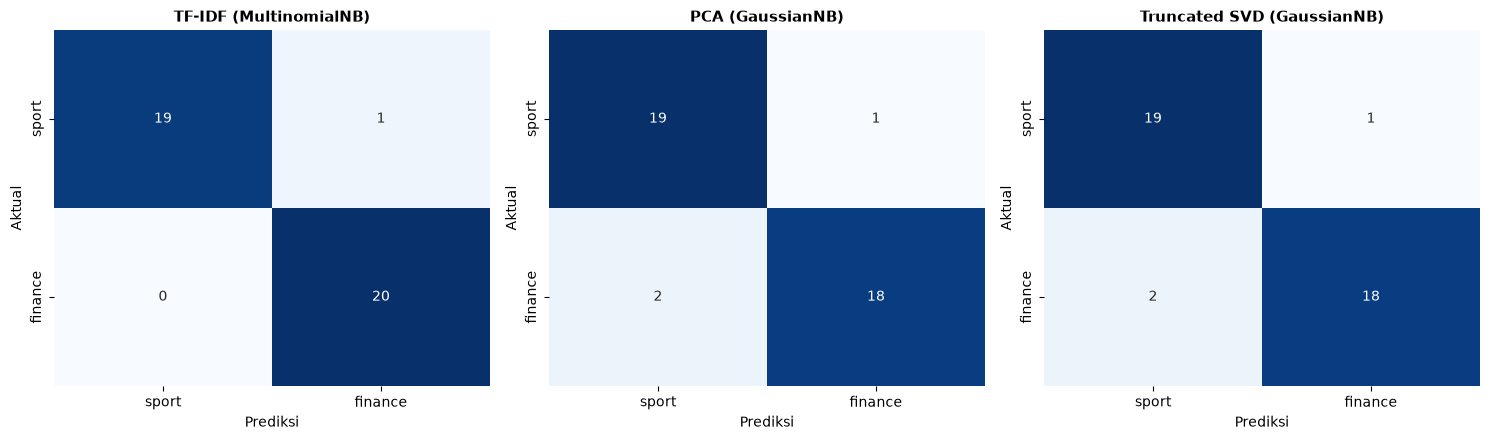

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, h in zip(axes, semua_hasil):
    cm = confusion_matrix(h["y_uji"], h["prediksi"], labels=["sport", "finance"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["sport", "finance"], yticklabels=["sport", "finance"], cbar=False)
    ax.set_title(h["nama"], fontsize=11, fontweight="bold")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.show()

## Ringkasan

- Ketiga representasi (TF-IDF, PCA, Truncated SVD) dievaluasi menggunakan pembagian data latih/uji yang identik untuk memastikan perbandingan yang adil.
- **TF-IDF** menggunakan seluruh fitur (kata unik) tanpa reduksi, sedangkan **PCA** dan **SVD** menggunakan fitur yang jauh lebih sedikit hasil reduksi dimensi.
- Perbandingan akurasi di atas menunjukkan trade-off antara jumlah fitur (dan biaya komputasi) dengan performa klasifikasi - apakah reduksi dimensi mengorbankan akurasi secara signifikan, atau justru performanya setara (atau lebih baik) dibanding representasi penuh.
- Hasil ini menjadi dasar untuk tahap **Evaluation** berikutnya, termasuk analisis lebih lanjut mengenai representasi mana yang paling sesuai untuk deployment.